# # AQI prediction model
# Load data, perform EDA, preprocess, train baseline and RandomForest models, and generate evaluation plots and save best model.

In [16]:
# Imports and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

SEED = 42
DATA_PATH = "data/full_merged_with_aqi.csv"
sns.set_style('whitegrid')
sns.set(rc={'figure.figsize':(9,6)})
print('Setup done. DATA_PATH:', DATA_PATH)

Setup done. DATA_PATH: data/full_merged_with_aqi.csv


In [17]:
# Load dataset and initial inspection
print('Loading', DATA_PATH)
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()


Loading data/full_merged_with_aqi.csv
Shape: (228246, 38)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,precipcover,windspeed,sealevelpressure,tempmax_humidity,tempmin_humidity,temp_humidity,temp_range,heat_index,conditions,AQI
0,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
1,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
2,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
3,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
4,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226


Detected AQI column: AQI


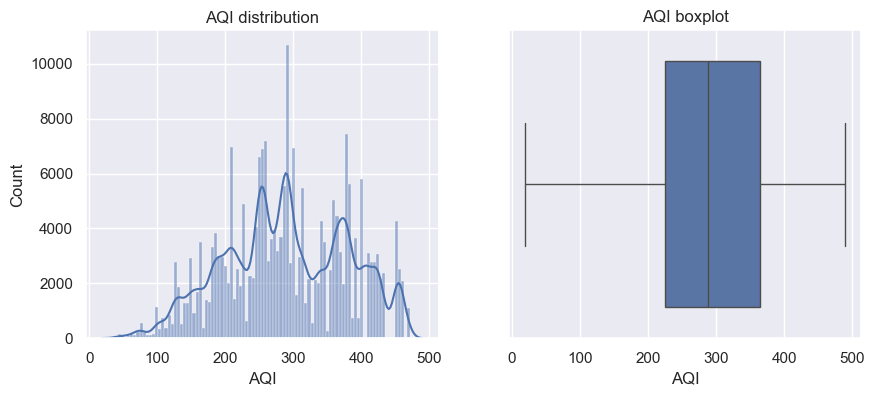

count    228246.000000
mean        289.535107
std          90.508392
min          19.000000
25%         225.000000
50%         288.000000
75%         365.000000
max         490.000000
Name: AQI, dtype: float64


In [18]:
# Detect target column and show distribution
aqi_col = next((c for c in df.columns if 'aqi' in c.lower()), None)
print('Detected AQI column:', aqi_col)

if aqi_col is None:
    raise ValueError('No AQI-like column found in dataset')

# Target distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df[aqi_col].dropna(), kde=True)
plt.title('AQI distribution')

plt.subplot(1,2,2)
sns.boxplot(x=df[aqi_col].dropna())
plt.title('AQI boxplot')
plt.show()

print(df[aqi_col].describe())


In [19]:
# Missing values and columns to drop
missing = df.isna().mean().sort_values(ascending=False)
missing.head(12)

# Drop columns with >50% missing and constant columns and obvious ids
drop_th = 0.5
cols_to_drop = missing[missing > drop_th].index.tolist()
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
id_cols = [c for c in df.columns if 'id' in c.lower() or c.lower().startswith('unnamed')]
print('cols_to_drop (by missing>50%):', cols_to_drop)
print('constant cols:', const_cols)
print('id-like cols:', id_cols)

cols_to_drop_final = list(set(cols_to_drop + const_cols + id_cols))
print('Dropping', len(cols_to_drop_final), 'columns')

df2 = df.drop(columns=cols_to_drop_final, errors='ignore').copy()
print('New shape:', df2.shape)


cols_to_drop (by missing>50%): []
constant cols: ['satellite', 'instrument', 'version']
id-like cols: ['confidence', 'humidity', 'tempmax_humidity', 'tempmin_humidity', 'temp_humidity']
Dropping 8 columns
New shape: (228246, 30)


windspeed                             -0.409042
sealevelpressure                       0.359700
feelslike                             -0.316705
feelslikemin                          -0.302476
feelslikemax                          -0.299953
Telemetry Hourly Wind Speed (Km/Hr)    0.292817
tempmin                               -0.292384
heat_index                             0.291715
temp                                  -0.280429
tempmax                               -0.243620
precipcover                           -0.179270
precipprob                            -0.169894
Latitude                              -0.153800
latitude                              -0.137871
bright_t31                            -0.106576
track                                 -0.085106
type                                  -0.083870
Longitude                              0.077724
dist_to_delhi                         -0.073393
precip                                -0.072756
Name: AQI, dtype: float64

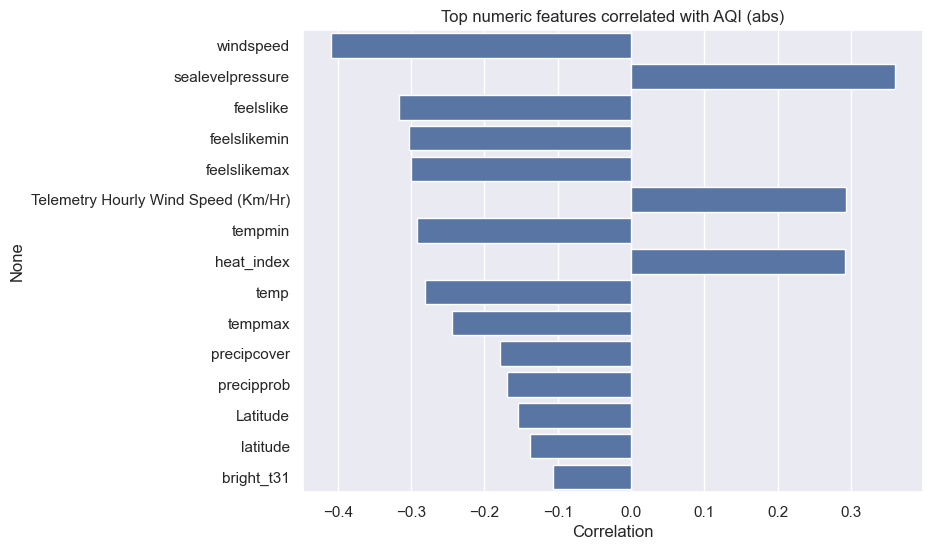

In [20]:
# Correlation with AQI (numeric features)
num_df = df2.select_dtypes(include=[np.number]).copy()
if aqi_col in num_df.columns:
    corr_with_aqi = num_df.corr()[aqi_col].drop(index=aqi_col).sort_values(key=lambda x: x.abs(), ascending=False)
    display(corr_with_aqi.head(20))
    plt.figure(figsize=(8,6))
    sns.barplot(x=corr_with_aqi.head(15).values, y=corr_with_aqi.head(15).index)
    plt.title('Top numeric features correlated with AQI (abs)')
    plt.xlabel('Correlation')
    plt.show()
else:
    print('AQI column not numeric in filtered dataset')


In [21]:
# Prepare features and target
# Drop rows with missing target
df2 = df2.dropna(subset=[aqi_col]).copy()
X = df2.drop(columns=[aqi_col])
y = df2[aqi_col].astype(float)

# numeric and categorical features
numeric_feats = X.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X.select_dtypes(include=['object','category','bool']).columns.tolist()
# also treat low-cardinality integer features as categorical
low_card_ints = [c for c in numeric_feats if X[c].nunique() <= 20]
for c in low_card_ints:
    if c not in cat_feats:
        cat_feats.append(c)
        numeric_feats.remove(c)

print('Numeric features:', len(numeric_feats))
print('Categorical features:', len(cat_feats))


Numeric features: 21
Categorical features: 8


In [23]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_feats),
    ('cat', cat_transformer, cat_feats)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (182596, 29) Test shape: (45650, 29)


In [24]:
# Baseline: Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

def regression_metrics(y_true, y_pred):
    return {
        'r2': r2_score(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred)
    }

metrics_lr = regression_metrics(y_test, y_pred_lr)
print('Linear Regression test metrics:', metrics_lr)


Linear Regression test metrics: {'r2': 0.9996016445780742, 'rmse': np.float64(1.809114442302295), 'mae': 0.04093621693308758}


In [ ]:
# Random Forest: Grid search
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 3]
}

grid = GridSearchCV(rf_pipeline, param_grid, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error', verbose=1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)

best_rf = grid.best_estimator_
# Evaluate on test set
y_pred_rf = best_rf.predict(X_test)
metrics_rf = regression_metrics(y_test, y_pred_rf)
print('RandomForest test metrics:', metrics_rf)


In [ ]:
# Prediction diagnostics and plots
# Predicted vs Actual
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Predicted vs Actual (RF)')

# Residuals
residuals = y_test - y_pred_rf
plt.subplot(1,2,2)
sns.histplot(residuals, kde=True)
plt.title('Residuals (RF)')
plt.show()

# Feature importances
# Get feature names after preprocessing
feature_names = []
if hasattr(best_rf.named_steps['preprocessor'], 'get_feature_names_out'):
    try:
        feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
    except Exception:
        # fallback: build names manually
        num_names = numeric_feats
        cat_ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
        cat_cols = cat_feats
        if hasattr(cat_ohe, 'get_feature_names_out'):
            ohe_names = cat_ohe.get_feature_names_out(cat_cols)
        else:
            ohe_names = []
        feature_names = list(num_names) + list(ohe_names)
else:
    # manual fallback
    num_names = numeric_feats
    cat_ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
    cat_cols = cat_feats
    if hasattr(cat_ohe, 'get_feature_names_out'):
        ohe_names = cat_ohe.get_feature_names_out(cat_cols)
    else:
        ohe_names = []
    feature_names = list(num_names) + list(ohe_names)

importances = best_rf.named_steps['model'].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
fi.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances (RF)')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Save best model and metrics
os.makedirs('results/models', exist_ok=True)
joblib.dump(best_rf, 'results/models/RF_aqi_model.joblib')
print('Saved best model to results/models/RF_aqi_model.joblib')

metrics_df = pd.DataFrame([metrics_lr, metrics_rf], index=['LinearRegression','RandomForest'])
metrics_df.to_csv('results/aqi_model_metrics.csv')
print('Saved metrics to results/aqi_model_metrics.csv')

display(metrics_df)


In [25]:
# Check for leakage: exact matches and very high correlations
leaky_cols = []
for c in X.columns:
    # check exact equality
    try:
        if X[c].isnull().all():
            continue
        if np.allclose(X[c].fillna(0).astype(float).values, y.fillna(0).astype(float).values):
            leaky_cols.append((c, 'exact'))
    except Exception:
        pass

# high correlation
num_corrs = X.select_dtypes(include=[np.number]).corrwith(y).abs().sort_values(ascending=False)
high_corr = num_corrs[num_corrs > 0.95]

print('Exact-match leaky cols:', leaky_cols)
print('High-corr cols (>0.95):')
print(high_corr.head())

# Show top 10 numeric correlations
print('\nTop numeric correlations with AQI:')
print(num_corrs.head(20))


Exact-match leaky cols: []
High-corr cols (>0.95):
Series([], dtype: float64)

Top numeric correlations with AQI:
windspeed                              0.409042
sealevelpressure                       0.359700
feelslike                              0.316705
feelslikemin                           0.302476
feelslikemax                           0.299953
Telemetry Hourly Wind Speed (Km/Hr)    0.292817
tempmin                                0.292384
heat_index                             0.291715
temp                                   0.280429
tempmax                                0.243620
precipcover                            0.179270
precipprob                             0.169894
Latitude                               0.153800
latitude                               0.137871
bright_t31                             0.106576
track                                  0.085106
type                                   0.083870
Longitude                              0.077724
dist_to_delhi         

In [26]:
# Inspect LR predictions on test set
print('y_test sample:')
print(y_test.head(10).values)
print('\nLR predictions sample:')
print(y_pred_lr[:10])

diff = y_test.values - y_pred_lr
print('\nPrediction diff stats:')
print('mean diff:', np.mean(diff), 'std diff:', np.std(diff), 'max abs diff:', np.max(np.abs(diff)))

# Show cases with largest absolute errors
err_idx = np.argsort(np.abs(diff))[-10:][::-1]
print('\nTop 10 absolute errors (index in test set):')
for i in err_idx:
    print(i, 'actual:', y_test.values[i], 'pred:', y_pred_lr[i], 'abs_err:', abs(diff[i]))


y_test sample:
[191. 236. 200. 403. 368. 300. 163. 241. 298. 279.]

LR predictions sample:
[191.03312057 236.00054148 200.04113285 403.00069849 368.00181142
 299.99792941 163.0218679  240.99943417 297.9812901  279.01363194]

Prediction diff stats:
mean diff: 0.009774611899319746 std diff: 1.8090880360858512 max abs diff: 321.5681502434295

Top 10 absolute errors (index in test set):
14963 actual: 389.0 pred: 67.4318497565705 abs_err: 321.5681502434295
14840 actual: 413.0 pred: 265.88379856645486 abs_err: 147.11620143354514
36956 actual: 81.0 pred: 146.1267279563912 abs_err: 65.12672795639119
31854 actual: 86.0 pred: 25.808163114450025 abs_err: 60.191836885549975
20098 actual: 96.0 pred: 145.32930334212807 abs_err: 49.32930334212807
13778 actual: 96.0 pred: 145.32930334212807 abs_err: 49.32930334212807
19909 actual: 124.0 pred: 75.94117199904514 abs_err: 48.05882800095486
4817 actual: 124.0 pred: 75.94117199904514 abs_err: 48.05882800095486
36201 actual: 66.0 pred: 111.44322360807348 ab

In [27]:
# Check training metrics for Linear Regression
y_pred_train_lr = lr_pipeline.predict(X_train)
metrics_train_lr = regression_metrics(y_train, y_pred_train_lr)
print('Linear Regression train metrics:', metrics_train_lr)
print('\nTrain residuals std:', np.std(y_train - y_pred_train_lr))
print('Test residuals std:', np.std(y_test - y_pred_lr))


Linear Regression train metrics: {'r2': 0.9999994931185664, 'rmse': np.float64(0.06441378163159352), 'mae': 0.018581826238796527}

Train residuals std: 0.06441378163159352
Test residuals std: 1.8090880360858512


In [28]:
# Look for datetime/time columns and evaluate temporal leakage
date_cols = [c for c in df2.columns if 'date' in c.lower() or 'time' in c.lower() or 'hour' in c.lower()]
print('Potential date/time columns:', date_cols)
# show a few rows of possible date columns
if date_cols:
    display(df2[date_cols].head())


Potential date/time columns: ['acq_date', 'acq_time', 'Telemetry Hourly Wind Speed (Km/Hr)']


,acq_date,acq_time,Telemetry Hourly Wind Speed (Km/Hr)
0,2021-04-12,653.0,40.4
1,2021-04-12,653.0,40.4
2,2021-04-12,653.0,40.4
3,2021-04-12,653.0,40.4
4,2021-04-12,653.0,40.4


In [29]:
# Time-based split if date available (chronological split by acq_date)
X_time = X.copy()
df_time = df2.copy()
if 'acq_date' in df_time.columns:
    df_time['acq_date'] = pd.to_datetime(df_time['acq_date'], errors='coerce')
    uniq_dates = np.sort(df_time['acq_date'].dropna().unique())
    cutoff = uniq_dates[int(len(uniq_dates)*0.8)]
    print('Using cutoff date for time split:', cutoff)
    train_mask = df_time['acq_date'] <= cutoff
    X_train_t = X_time[train_mask]
    y_train_t = y[train_mask]
    X_test_t = X_time[~train_mask]
    y_test_t = y[~train_mask]
    print('Time-split train shape:', X_train_t.shape, 'test shape:', X_test_t.shape)
else:
    print('No acq_date column found; skipping time-based split')


Using cutoff date for time split: 2024-05-01T00:00:00.000000000
Time-split train shape: (173254, 29) test shape: (54992, 29)


Training LR on time split...
LR time-split metrics: {'r2': -0.6649450940931874, 'rmse': np.float64(92.65216007359183), 'mae': 75.49440688614712}
Running RF grid search on time split (this may take a while)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params (time-split): {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
RF time-split metrics: {'r2': -0.2549956119547294, 'rmse': np.float64(80.4408580399269), 'mae': 60.859774795509956}


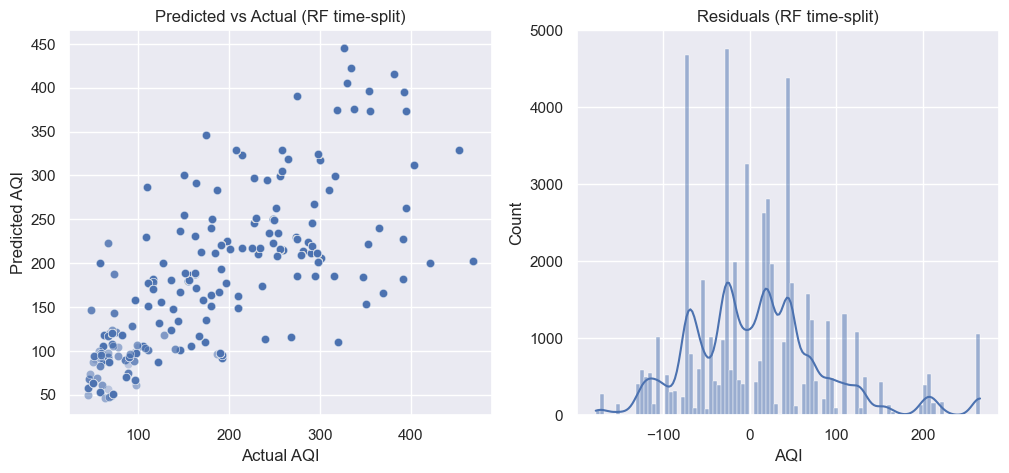

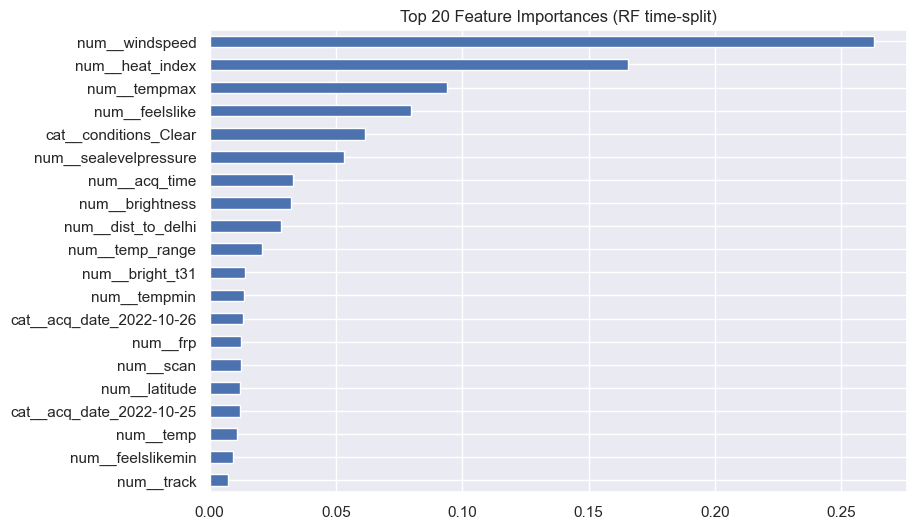

Saved time-split model and metrics


,r2,rmse,mae
LinearRegression_time,-0.664945,92.652160,75.494407
RandomForest_time,-0.254996,80.440858,60.859775


In [30]:
# Train and evaluate on time-based split
print('Training LR on time split...')
lr_pipeline_t = Pipeline(steps=[('preprocessor', preprocessor),('model', LinearRegression())])
lr_pipeline_t.fit(X_train_t, y_train_t)
y_pred_lr_t = lr_pipeline_t.predict(X_test_t)
metrics_lr_t = regression_metrics(y_test_t, y_pred_lr_t)
print('LR time-split metrics:', metrics_lr_t)

# Random Forest on time split (grid search)
print('Running RF grid search on time split (this may take a while)...')
rf_pipeline_t = Pipeline(steps=[('preprocessor', preprocessor),('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))])
param_grid_t = {'model__n_estimators':[100], 'model__max_depth':[20,None], 'model__min_samples_leaf':[1,3]}

grid_t = GridSearchCV(rf_pipeline_t, param_grid_t, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error', verbose=1)
grid_t.fit(X_train_t, y_train_t)
print('Best params (time-split):', grid_t.best_params_)
best_rf_t = grid_t.best_estimator_
y_pred_rf_t = best_rf_t.predict(X_test_t)
metrics_rf_t = regression_metrics(y_test_t, y_pred_rf_t)
print('RF time-split metrics:', metrics_rf_t)

# Plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=y_test_t, y=y_pred_rf_t, alpha=0.3)
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Predicted vs Actual (RF time-split)')

plt.subplot(1,2,2)
sns.histplot(y_test_t - y_pred_rf_t, kde=True)
plt.title('Residuals (RF time-split)')
plt.show()

# Feature importances (time split)
# get feature names like before
try:
    feature_names_t = best_rf_t.named_steps['preprocessor'].get_feature_names_out()
except Exception:
    num_names = numeric_feats
    cat_ohe = best_rf_t.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
    cat_cols = cat_feats
    if hasattr(cat_ohe, 'get_feature_names_out'):
        ohe_names = cat_ohe.get_feature_names_out(cat_cols)
    else:
        ohe_names = []
    feature_names_t = list(num_names) + list(ohe_names)

importances_t = best_rf_t.named_steps['model'].feature_importances_
fi_t = pd.Series(importances_t, index=feature_names_t).sort_values(ascending=False)
fi_t.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances (RF time-split)')
plt.gca().invert_yaxis()
plt.show()

# Save time-split model and metrics
joblib.dump(best_rf_t, 'results/models/RF_aqi_model_time_split.joblib')
metrics_df_time = pd.DataFrame([metrics_lr_t, metrics_rf_t], index=['LinearRegression_time','RandomForest_time'])
metrics_df_time.to_csv('results/aqi_model_metrics_time_split.csv')
print('Saved time-split model and metrics')

display(metrics_df_time)


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

In [3]:
data = pd.read_csv('data/full_merged_with_aqi.csv')
data.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,dist_to_delhi,Latitude,Longitude,Telemetry Hourly Wind Speed (Km/Hr),tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,precipcover,windspeed,sealevelpressure,tempmax_humidity,tempmin_humidity,temp_humidity,temp_range,heat_index,conditions,AQI
0,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,2.0,299.59,52.2,D,0.0,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,37.0,20.9,28.8,28.0,0.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
1,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,2.0,299.59,52.2,D,0.0,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,37.0,20.9,28.8,28.0,0.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
2,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,2.0,299.59,52.2,D,0.0,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,37.0,20.9,28.8,28.0,0.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
3,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,2.0,299.59,52.2,D,0.0,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,37.0,20.9,28.8,28.0,0.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
4,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,2.0,299.59,52.2,D,0.0,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,37.0,20.9,28.8,28.0,0.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226


In [4]:
data.columns

Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight', 'type', 'dist_to_delhi', 'Latitude',
       'Longitude', 'Telemetry Hourly Wind Speed (Km/Hr)', 'tempmax',
       'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike',
       'humidity', 'precip', 'precipprob', 'precipcover', 'windspeed',
       'sealevelpressure', 'tempmax_humidity', 'tempmin_humidity',
       'temp_humidity', 'temp_range', 'heat_index', 'conditions', 'AQI'],
      dtype='object')

In [5]:
data['type'].unique()

array([0., 2.])

In [8]:
cols_to_drop = ['scan', 'track', 'acq_time', 
                'satellite', 'instrument', 'confidence', 
                'version', 'type', 'latitude', 'longitude',
                'feelslike', 'feelslikemax', 'feelslikemin',
                'precipprob']

data.drop(columns=cols_to_drop, inplace=True)

In [9]:
data.head()

,brightness,acq_date,bright_t31,frp,daynight,dist_to_delhi,Latitude,Longitude,Telemetry Hourly Wind Speed (Km/Hr),tempmax,tempmin,temp,humidity,precip,precipcover,windspeed,sealevelpressure,tempmax_humidity,tempmin_humidity,temp_humidity,temp_range,heat_index,conditions,AQI
0,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,28.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
1,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,28.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
2,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,28.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
3,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,28.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
4,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,20.9,29.8,28.0,0.0,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226


In [10]:
data.tail()

,brightness,acq_date,bright_t31,frp,daynight,dist_to_delhi,Latitude,Longitude,Telemetry Hourly Wind Speed (Km/Hr),tempmax,tempmin,temp,humidity,precip,precipcover,windspeed,sealevelpressure,tempmax_humidity,tempmin_humidity,temp_humidity,temp_range,heat_index,conditions,AQI
228241,330.23,2024-11-30,301.4,2.73,D,62.343058,32.443262,75.731494,1.13,25.0,11.0,18.0,63.3,0.0,0.0,11.2,1015.5,1582.5,696.3,1139.4,14.0,242.753801,Clear,351
228242,330.23,2024-11-30,301.4,2.73,D,62.343058,32.443262,75.731494,1.13,25.0,11.0,18.0,63.3,0.0,0.0,11.2,1015.5,1582.5,696.3,1139.4,14.0,242.753801,Clear,351
228243,330.23,2024-11-30,301.4,2.73,D,62.343058,32.443262,75.731494,1.13,25.0,11.0,18.0,63.3,0.0,0.0,11.2,1015.5,1582.5,696.3,1139.4,14.0,242.753801,Clear,351
228244,330.23,2024-11-30,301.4,2.73,D,62.343058,32.443262,75.731494,1.13,25.0,11.0,18.0,63.3,0.0,0.0,11.2,1015.5,1582.5,696.3,1139.4,14.0,242.753801,Clear,351
228245,330.23,2024-11-30,301.4,2.73,D,62.343058,32.443262,75.731494,1.13,25.0,11.0,18.0,63.3,0.0,0.0,11.2,1015.5,1582.5,696.3,1139.4,14.0,242.753801,Clear,351
